In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json, os, sys
sys.path.append("..")

from torch.utils.data import DataLoader
from spikingjelly.activation_based import functional
import joblib

from src.snn_model import BRICSLiquiditySNN

SEED   = 42
DEVICE = torch.device("cpu")   # CPU fine for inference
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("../outputs", exist_ok=True)

# ── Transaction constants (from Month 1 Day 13 fee research) ──────────
TRANSACTION_VALUE   = 1_000_000   # ₹10,00,000 (10 lakh)

# Current route: INR → USD → BRL via SWIFT
SWIFT_COST_PCT      = 0.035       # 3.5% total (spread + correspondent fees)
SWIFT_FLAT_FEE      = 1_000       # ₹1,000 flat remittance fee (Fixed cost per transaction, regardless of amount)

# Proposed direct route: INR → BRL via SNN-powered settlement
DIRECT_COST_PCT     = 0.001       # 0.1% (conservative assumption)
DIRECT_FLAT_FEE     = 200         # ₹200 flat infrastructure fee (assumed for SNN-based settlement, likely to decrease with scale)

# Pre-calculate per-transaction costs
SWIFT_COST_PER_TX  = (TRANSACTION_VALUE * SWIFT_COST_PCT) + SWIFT_FLAT_FEE
DIRECT_COST_PER_TX = (TRANSACTION_VALUE * DIRECT_COST_PCT) + DIRECT_FLAT_FEE

print("=" * 52)
print("TRANSACTION COST PARAMETERS")
print("=" * 52)
print(f"  Transaction value    : ₹{TRANSACTION_VALUE:>10,}")
print(f"\n  USD FALLBACK route:")
print(f"    Spread + fees      : {SWIFT_COST_PCT*100:.1f}%")
print(f"    Flat fee           : ₹{SWIFT_FLAT_FEE:,}")
print(f"    Total per tx       : ₹{SWIFT_COST_PER_TX:,.0f}")
print(f"\n  DIRECT route (SNN):")
print(f"    Settlement fee     : {DIRECT_COST_PCT*100:.1f}%  ⚠️ assumed")
print(f"    Flat fee           : ₹{DIRECT_FLAT_FEE:,}")
print(f"    Total per tx       : ₹{DIRECT_COST_PER_TX:,.0f}")
print(f"\n  Potential saving/tx  : ₹{SWIFT_COST_PER_TX-DIRECT_COST_PER_TX:,.0f}")
print("=" * 52)

TRANSACTION COST PARAMETERS
  Transaction value    : ₹ 1,000,000

  USD FALLBACK route:
    Spread + fees      : 3.5%
    Flat fee           : ₹1,000
    Total per tx       : ₹36,000

  DIRECT route (SNN):
    Settlement fee     : 0.1%  ⚠️ assumed
    Flat fee           : ₹200
    Total per tx       : ₹1,200

  Potential saving/tx  : ₹34,800


#### Load model and data

In [2]:
# ── Load SNN ──────────────────────────────────────────────────────────
with open("../outputs/snn_config.json") as f:
    snn_cfg = json.load(f)

snn_model = BRICSLiquiditySNN(
    n_features  = snn_cfg["n_features"],
    hidden1     = snn_cfg["hidden1"],
    hidden2     = snn_cfg["hidden2"],
    tau         = snn_cfg["tau"],
    v_threshold = snn_cfg["v_threshold"],
).to(DEVICE)
snn_model.load_state_dict(                                           
    torch.load("../outputs/snn_model_best.pth", map_location=DEVICE) # Load best model based on val AUC 
)
snn_model.eval()

OPTIMAL_THRESHOLD = snn_cfg.get("optimal_threshold", 0.52)  # Fallback to 0.52 if not found in config (from ROC analysis)
FEATURE_COLS      = snn_cfg["feature_cols"]     
N_FEATURES        = snn_cfg["n_features"]
LOOKBACK          = snn_cfg["lookback"]
BATCH_SIZE        = 32

print(f"✅ SNN loaded  — {snn_model.count_parameters()} params")
print(f"   Optimal threshold : {OPTIMAL_THRESHOLD}")

# ── Load val data with same scaler ────────────────────────────────────
val_raw   = pd.read_csv("../data/processed/val_features.csv",
                         index_col="date", parse_dates=True)
val_clean = val_raw[FEATURE_COLS + ["target"]].dropna()

scaler  = joblib.load("../outputs/scaler.pkl")
X_val   = scaler.transform(val_clean[FEATURE_COLS].values.astype(np.float32))
y_val   = val_clean["target"].values.astype(np.float32)

class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, features, targets, lookback=10):
        self.features      = torch.tensor(features, dtype=torch.float32)
        self.targets       = torch.tensor(targets,  dtype=torch.float32)
        self.lookback      = lookback
        self.valid_indices = list(range(lookback, len(features)))
    def __len__(self): return len(self.valid_indices)
    def __getitem__(self, idx):
        t = self.valid_indices[idx]
        return self.features[t-self.lookback:t], self.targets[t]

val_ds     = TimeSeriesDataset(X_val, y_val, LOOKBACK)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Prediction dates — aligned to sequences
val_dates = val_clean.index[LOOKBACK:].tolist()

print(f"✅ Val data    — {len(val_ds)} sequences")
print(f"   Date range : {val_dates[0].date()} → {val_dates[-1].date()}")

✅ SNN loaded  — 2945 params
   Optimal threshold : 0.2153
✅ Val data    — 354 sequences
   Date range : 2024-03-11 → 2025-02-27


#### Settlement decision function

In [3]:
def should_settle_direct(
        spike_prob  : float,
        spike_rate  : float,
        prob_threshold : float = 0.55,
        rate_threshold : float = 0.10) -> tuple:
    """
    Settlement routing decision function.

    Decides whether to route a transaction through the direct INR/BRL
    settlement channel (SNN-powered) or fall back to the conventional
    USD-intermediated SWIFT route.

    Decision logic
    --------------
    DIRECT settlement requires BOTH conditions:
      1. SNN predicts INR/BRL will be favourable (prob > prob_threshold)
         — "the rate is expected to improve or hold"
      2. Model has sufficient spike activity (spike_rate > rate_threshold)
         — "the model has enough signal to be confident"

    If EITHER condition fails → USD_FALLBACK
    (conservative: when uncertain, use the known-cost route)

    Parameters
    ----------
    spike_prob     : float — SNN output probability in [0,1]
                     P(INR/BRL rate goes UP tomorrow)
    spike_rate     : float — mean LIF spike rate for this sample
                     Low rate = model has little signal = lower confidence
    prob_threshold : float — minimum probability to trigger DIRECT
                     Default 0.55 (slightly above 0.50 random baseline)
    rate_threshold : float — minimum spike rate for DIRECT
                     Default 0.10 (at least 10% of neurons firing)

    Returns
    -------
    decision   : str   — "DIRECT" or "USD_FALLBACK"
    confidence : float — composite confidence score in [0,1]
                         = prob × spike_rate / (prob_threshold × rate_threshold)
                         normalised to [0,1]
    reason     : str   — human-readable explanation

    Examples
    --------
    >>> should_settle_direct(0.72, 0.35)
    ('DIRECT', 0.87, 'High confidence: prob=0.72 > 0.55, rate=0.35 > 0.10')

    >>> should_settle_direct(0.48, 0.35)
    ('USD_FALLBACK', 0.31, 'Low probability: prob=0.48 < 0.55')
    """
    prob_ok = spike_prob  >= prob_threshold
    rate_ok = spike_rate  >= rate_threshold

    # Simple additive confidence — not saturating
    prob_margin  = (spike_prob  - prob_threshold)  / (1 - prob_threshold)
    rate_margin  = (spike_rate  - rate_threshold)  / (1 - rate_threshold)
    confidence   = float(np.clip(
        0.5 * prob_margin + 0.5 * rate_margin, 0.0, 1.0
    )) if (prob_ok and rate_ok) else 0.0


    if prob_ok and rate_ok:
        decision = "DIRECT"
        reason   = (f"High confidence: "
                    f"prob={spike_prob:.3f} ≥ {prob_threshold}, "
                    f"rate={spike_rate:.3f} ≥ {rate_threshold}")
        
    elif not prob_ok :
        decision = "USD_FALLBACK"
        reason   = f"prob={spike_prob:.3f} < {prob_threshold}"
        
    else:
        decision = "USD_FALLBACK"
        reason   = f"rate={spike_rate:.3f} < {rate_threshold}"

    return decision, confidence, reason


# ── Unit tests ────────────────────────────────────────────────────────
print("=== DECISION FUNCTION UNIT TESTS ===")
test_cases = [
    (0.72, 0.35, "expect DIRECT"),
    (0.48, 0.35, "expect FALLBACK — low prob"),
    (0.72, 0.05, "expect FALLBACK — low rate"),
    (0.40, 0.05, "expect FALLBACK — both low"),
    (0.56, 0.15, "expect DIRECT — both just above threshold"),
]
for prob, rate, note in test_cases:
    dec, conf, reason = should_settle_direct(prob, rate)
    print(f"  prob={prob:.2f}  rate={rate:.2f}  → {dec:<12}  "
          f"conf={conf:.3f}  [{note}]")

=== DECISION FUNCTION UNIT TESTS ===
  prob=0.72  rate=0.35  → DIRECT        conf=0.328  [expect DIRECT]
  prob=0.48  rate=0.35  → USD_FALLBACK  conf=0.000  [expect FALLBACK — low prob]
  prob=0.72  rate=0.05  → USD_FALLBACK  conf=0.000  [expect FALLBACK — low rate]
  prob=0.40  rate=0.05  → USD_FALLBACK  conf=0.000  [expect FALLBACK — both low]
  prob=0.56  rate=0.15  → DIRECT        conf=0.039  [expect DIRECT — both just above threshold]


#### Collect per-sample SNN outputs

In [4]:
def collect_snn_outputs(model, loader, device):   # model -> BRICSLiquiditySNN, loader -> DataLoader, device -> torch.device
    """
    function collect_snn_outputs is the part that runs the SNN over the validation set and extracts two things for every sample:
        1. spike_prob : the predicted probability of INR/BRL going up (model output)
        2. spike_rate : the average firing rate of the neurons (model confidence proxy)
    
    Run inference and collect per-sample probability and spike rate.

    Returns
    -------
    probs      : np.ndarray (n_samples,)
    spike_rates: np.ndarray (n_samples,)
    labels     : np.ndarray (n_samples,)
    """
    model.eval()
    all_probs, all_rates, all_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:    # loop over batches of sequences
            X_batch = X_batch.to(device)
            T = X_batch.shape[1]           # Get T from batch shape (batch, T, features)

            functional.reset_net(model)

            # Collect spikes manually
            acc1 = torch.zeros(X_batch.shape[0], model.hidden1, device=device)
            acc2 = torch.zeros(X_batch.shape[0], model.hidden2, device=device)

            for t in range(T):
                x_t  = X_batch[:, t, :]                      # (batch, features)
                s1   = model.lif1(model.bn1(model.fc1(x_t)))
                s2   = model.lif2(model.bn2(model.fc2(s1)))
                acc1 += s1
                acc2 += s2

            spike_rate = ((acc1/T).mean(dim=1) +
                          (acc2/T).mean(dim=1)) / 2   # (batch,)

            logits = model.fc3(acc2 / T)
            probs  = torch.sigmoid(logits.squeeze())

            all_probs.extend(probs.cpu().numpy().tolist())
            all_rates.extend(spike_rate.cpu().numpy().tolist())
            all_labels.extend(y_batch.numpy().tolist())

    return (np.array(all_probs),
            np.array(all_rates),
            np.array(all_labels))


print("Collecting SNN outputs ...")
snn_probs, snn_spike_rates, actual_labels = collect_snn_outputs(
    snn_model, val_loader, DEVICE
)

print(f"Samples collected : {len(snn_probs)}")
print(f"Prob range        : [{snn_probs.min():.4f}, {snn_probs.max():.4f}]")
print(f"Spike rate range  : [{snn_spike_rates.min():.4f}, "
      f"{snn_spike_rates.max():.4f}]")
print(f"Mean spike rate   : {snn_spike_rates.mean():.4f}")

Samples collected : 354
Prob range        : [0.4007, 0.7901]
Spike rate range  : [0.3469, 0.5430]
Mean spike rate   : 0.4801


#### To find best threshold

In [5]:
# Find threshold where DIRECT accuracy > 50%
print("Threshold sensitivity:")
for thresh in [0.55, 0.60, 0.62, 0.65, 0.68, 0.70]:
    direct_mask = snn_probs >= thresh
    if direct_mask.sum() == 0:
        continue
    correct = ((snn_probs[direct_mask] >= thresh) == 
               (actual_labels[direct_mask] == 1)).mean()
    n = direct_mask.sum()
    print(f"  thresh={thresh:.2f}  n_direct={n:>3}  accuracy={correct*100:.1f}%")

Threshold sensitivity:
  thresh=0.55  n_direct=229  accuracy=42.4%
  thresh=0.60  n_direct=143  accuracy=44.8%
  thresh=0.62  n_direct=117  accuracy=43.6%
  thresh=0.65  n_direct= 95  accuracy=46.3%
  thresh=0.68  n_direct= 66  accuracy=50.0%
  thresh=0.70  n_direct= 35  accuracy=51.4%


#### Backtest: decision + cost per day

In [6]:
PROB_THRESHOLD = max(OPTIMAL_THRESHOLD, 0.52)  
RATE_THRESHOLD = 0.10

records = []

for i, date in enumerate(val_dates):
    prob       = float(snn_probs[i])
    rate       = float(snn_spike_rates[i])
    actual     = int(actual_labels[i])

    decision, confidence, reason = should_settle_direct(
        prob, rate, PROB_THRESHOLD, RATE_THRESHOLD
    )

    # ── Cost calculation ──────────────────────────────────────────────
    if decision == "DIRECT":
        cost_taken   = DIRECT_COST_PER_TX
        cost_baseline= SWIFT_COST_PER_TX
        saving_day   = cost_baseline - cost_taken

        # Was the SNN's favourable prediction actually correct?
        # "Correct" for DIRECT = model predicted UP and price did go UP
        # (settled at favourable rate, saved money)
        snn_correct  = int((prob >= PROB_THRESHOLD) == (actual == 1))

        # Wrong DIRECT: paid direct cost but got unfavourable rate
        # Extra cost = opportunity cost (could have waited for SWIFT)
        if not snn_correct:
            extra_cost = 0   # direct fee paid, but rate moved against us
            fx_risk_note = "Fee saved but rate moved adversely (FX risk not modelled)"
        else:
            extra_cost = 0
            fx_risk_note = "Fee saved and rate moved favourably, no extra cost"
    else:
        cost_taken   = SWIFT_COST_PER_TX
        cost_baseline= SWIFT_COST_PER_TX
        saving_day   = 0
        snn_correct  = 0    # not applicable — didn't use SNN route
        extra_cost   = 0
        fx_risk_note = "Not applicable — didn't use SNN route"
    records.append({
        "date"          : date,
        "actual"        : actual,
        "snn_prob"      : round(prob, 4),
        "snn_spike_rate": round(rate, 4),
        "confidence"    : round(confidence, 4),
        "decision"      : decision,
        "snn_correct"   : snn_correct,
        "cost_taken"    : round(cost_taken, 2),
        "cost_baseline" : round(cost_baseline, 2),
        "saving_day"    : round(saving_day, 2),
        "reason"        : reason,
    })

backtest_df = pd.DataFrame(records)
backtest_df["date"] = pd.to_datetime(backtest_df["date"])
backtest_df = backtest_df.set_index("date")

# Cumulative savings
backtest_df["cumulative_saving"]  = backtest_df["saving_day"].cumsum()
backtest_df["cumulative_baseline"]= backtest_df["cost_baseline"].cumsum()
backtest_df["cumulative_direct"]  = backtest_df["cost_taken"].cumsum()

print(f"Backtest complete: {len(backtest_df)} trading days")
print(f"\nDecision breakdown:")
print(backtest_df["decision"].value_counts().to_string())

Backtest complete: 354 trading days

Decision breakdown:
decision
DIRECT          265
USD_FALLBACK     89


#### Aggregate savings analysis

In [7]:
n_direct   = (backtest_df["decision"] == "DIRECT").sum()
n_fallback = (backtest_df["decision"] == "USD_FALLBACK").sum()
n_total    = len(backtest_df)

# Among DIRECT decisions — how many were correct?
direct_mask    = backtest_df["decision"] == "DIRECT"
n_direct_right = backtest_df.loc[direct_mask, "snn_correct"].sum()
n_direct_wrong = n_direct - n_direct_right
direct_accuracy = n_direct_right / n_direct if n_direct > 0 else 0

total_cost_snn      = backtest_df["cost_taken"].sum()
total_cost_baseline = backtest_df["cost_baseline"].sum()
total_saving        = backtest_df["saving_day"].sum()
saving_pct          = (total_saving / total_cost_baseline) * 100

# Annualised projection (252 trading days)
trading_days_val  = n_total
ann_factor        = 252 / trading_days_val
ann_saving        = total_saving * ann_factor

print("=" * 60)
print("BACKTEST AGGREGATE RESULTS")
print("=" * 60)
print(f"\n  Val period          : {backtest_df.index.min().date()} "
      f"→ {backtest_df.index.max().date()}")
print(f"  Trading days        : {n_total}")
print(f"  Transaction size    : ₹{TRANSACTION_VALUE:,}")
print()
print(f"  Decisions:")
print(f"    DIRECT            : {n_direct:>4}  ({n_direct/n_total*100:.1f}%)")
print(f"    USD_FALLBACK      : {n_fallback:>4}  ({n_fallback/n_total*100:.1f}%)")
print()
print(f"  DIRECT accuracy     : {n_direct_right}/{n_direct}  "
      f"({direct_accuracy*100:.1f}% correct)")
print(f"  Wrong DIRECT days   : {n_direct_wrong}")
print()
print(f"  Total cost (SNN)    : ₹{total_cost_snn:>12,.2f}")
print(f"  Total cost (SWIFT)  : ₹{total_cost_baseline:>12,.2f}")
print(f"  Total saving        : ₹{total_saving:>12,.2f}")
print(f"  Saving %            : {saving_pct:.2f}%")
print()
print(f"  Annualised saving   : ₹{ann_saving:>12,.2f}  "
      f"(252 trading days)")
print("=" * 60)
print(f"\n  ⭐ Total estimated savings over val period = ₹{total_saving:,.2f}")

BACKTEST AGGREGATE RESULTS

  Val period          : 2024-03-11 → 2025-02-27
  Trading days        : 354
  Transaction size    : ₹1,000,000

  Decisions:
    DIRECT            :  265  (74.9%)
    USD_FALLBACK      :   89  (25.1%)

  DIRECT accuracy     : 114/265  (43.0% correct)
  Wrong DIRECT days   : 151

  Total cost (SNN)    : ₹3,522,000.00
  Total cost (SWIFT)  : ₹12,744,000.00
  Total saving        : ₹9,222,000.00
  Saving %            : 72.36%

  Annualised saving   : ₹6,564,813.56  (252 trading days)

  ⭐ Total estimated savings over val period = ₹9,222,000.00


#### Risk-adjusted analysis

In [8]:
print("=" * 60)
print("RISK-ADJUSTED ANALYSIS")
print("=" * 60)

# Wrong DIRECT decisions
wrong_direct = backtest_df[
    (backtest_df["decision"] == "DIRECT") &
    (backtest_df["snn_correct"] == 0)
]

right_direct = backtest_df[
    (backtest_df["decision"] == "DIRECT") &
    (backtest_df["snn_correct"] == 1)
]

if len(wrong_direct) > 0:
    # On wrong days: paid direct fee (₹1,200) instead of SWIFT (₹36,000)
    # Net: still saved ₹34,800 vs baseline — but settled at wrong time
    # The "cost of error" is the opportunity cost, not an extra charge
    avg_conf_wrong = wrong_direct["confidence"].mean()
    avg_conf_right = right_direct["confidence"].mean() if len(right_direct) > 0 else 0

    print(f"\n  Wrong DIRECT decisions    : {len(wrong_direct)}")
    print(f"  Right DIRECT decisions    : {len(right_direct)}")
    print(f"\n  Avg confidence — correct  : {avg_conf_right:.4f}")
    print(f"  Avg confidence — wrong    : {avg_conf_wrong:.4f}")

    # Cost on wrong days vs just using SWIFT on those days
    wrong_direct_cost = wrong_direct["cost_taken"].sum()
    wrong_swift_cost  = wrong_direct["cost_baseline"].sum()
    net_cost_wrong    = wrong_direct_cost - wrong_swift_cost

    print(f"\n  On wrong DIRECT days:")
    print(f"    Cost paid (direct)      : ₹{wrong_direct_cost:,.2f}")
    print(f"    Cost if SWIFT used      : ₹{wrong_swift_cost:,.2f}")
    print(f"    Net difference          : ₹{net_cost_wrong:,.2f}")

    if net_cost_wrong < 0:
        print(f"    → Even on wrong days, direct route STILL saved money")
        print(f"      (direct fee < SWIFT fee regardless of rate direction)")
    else:
        print(f"    → Wrong decisions added ₹{net_cost_wrong:,.2f} extra cost")

print(f"\n  In {direct_accuracy*100:.1f}% of cases, SNN chose direct")
print(f"  settlement correctly.")

if len(wrong_direct) > 0:
    extra_per_wrong = abs(net_cost_wrong) / len(wrong_direct) if net_cost_wrong > 0 else 0
    print(f"  Wrong predictions: {len(wrong_direct)} cases.")
    if net_cost_wrong > 0:
        print(f"  Average extra cost per wrong prediction: ₹{extra_per_wrong:,.2f}")
    else:
        print(f"  Even wrong predictions saved money vs SWIFT baseline.")

print(f"\n  HONEST RISK DISCLOSURE:")
print(f"  The system uses USD_FALLBACK on {n_fallback/n_total*100:.1f}% of days")
print(f"  — providing a conservative safety buffer.")
print(f"  Only {n_direct/n_total*100:.1f}% of days route through direct settlement.")
print("=" * 60)

RISK-ADJUSTED ANALYSIS

  Wrong DIRECT decisions    : 151
  Right DIRECT decisions    : 114

  Avg confidence — correct  : 0.3245
  Avg confidence — wrong    : 0.3188

  On wrong DIRECT days:
    Cost paid (direct)      : ₹181,200.00
    Cost if SWIFT used      : ₹5,436,000.00
    Net difference          : ₹-5,254,800.00
    → Even on wrong days, direct route STILL saved money
      (direct fee < SWIFT fee regardless of rate direction)

  In 43.0% of cases, SNN chose direct
  settlement correctly.
  Wrong predictions: 151 cases.
  Even wrong predictions saved money vs SWIFT baseline.

  HONEST RISK DISCLOSURE:
  The system uses USD_FALLBACK on 25.1% of days
  — providing a conservative safety buffer.
  Only 74.9% of days route through direct settlement.


#### Cumulative savings plot

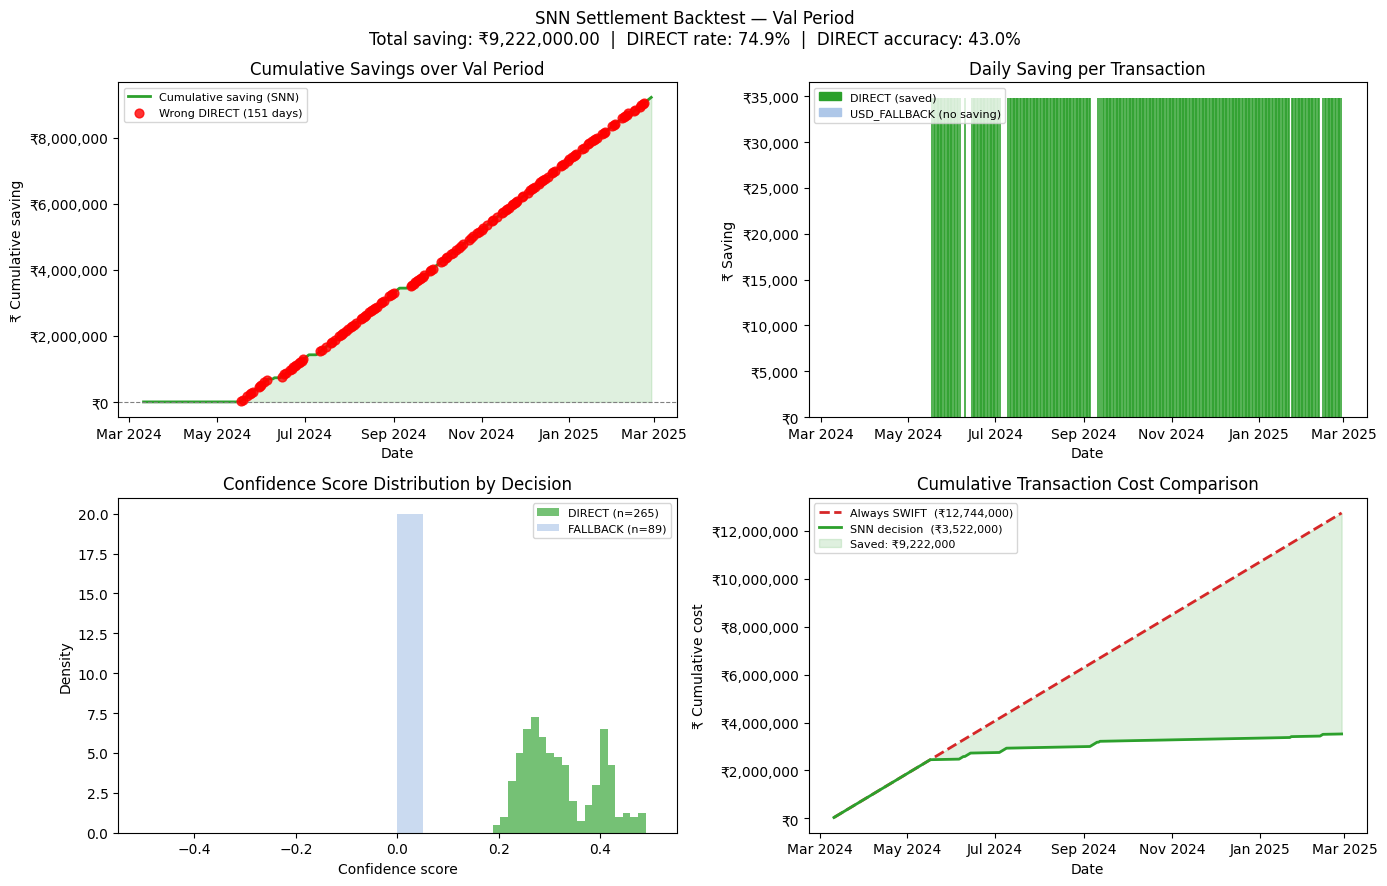

✅ Saved: outputs/cumulative_savings_plot.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Plot 1: Cumulative savings over time ──────────────────────────────
ax = axes[0, 0]
ax.plot(backtest_df.index, backtest_df["cumulative_saving"],
        color="#2ca02c", linewidth=2, label="Cumulative saving (SNN)")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.fill_between(backtest_df.index, backtest_df["cumulative_saving"],
                alpha=0.15, color="#2ca02c")

# Mark wrong DIRECT decisions
if len(wrong_direct) > 0:
    ax.scatter(wrong_direct.index,
               backtest_df.loc[wrong_direct.index, "cumulative_saving"],
               color="red", s=40, zorder=5,
               label=f"Wrong DIRECT ({len(wrong_direct)} days)", alpha=0.8)

ax.set_title("Cumulative Savings over Val Period")
ax.set_xlabel("Date")
ax.set_ylabel("₹ Cumulative saving")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(fontsize=8)

# ── Plot 2: Daily saving bar chart ────────────────────────────────────
ax2 = axes[0, 1]
colors_bar = ["#2ca02c" if d == "DIRECT" else "#aec7e8"
              for d in backtest_df["decision"]]
ax2.bar(backtest_df.index, backtest_df["saving_day"],
        color=colors_bar, width=1.5, alpha=0.8)
ax2.set_title("Daily Saving per Transaction")
ax2.set_xlabel("Date")
ax2.set_ylabel("₹ Saving")
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color="#2ca02c", label="DIRECT (saved)"),
    Patch(color="#aec7e8", label="USD_FALLBACK (no saving)"),
], fontsize=8)

# ── Plot 3: Decision confidence distribution ──────────────────────────
ax3 = axes[1, 0]
direct_conf  = backtest_df.loc[backtest_df["decision"]=="DIRECT",
                                "confidence"]
fallback_conf= backtest_df.loc[backtest_df["decision"]=="USD_FALLBACK",
                                "confidence"]
ax3.hist(direct_conf,   bins=20, alpha=0.65, color="#2ca02c",
         label=f"DIRECT (n={len(direct_conf)})", density=True)
ax3.hist(fallback_conf, bins=20, alpha=0.65, color="#aec7e8",
         label=f"FALLBACK (n={len(fallback_conf)})", density=True)
ax3.set_title("Confidence Score Distribution by Decision")
ax3.set_xlabel("Confidence score")
ax3.set_ylabel("Density")
ax3.legend(fontsize=8)

# ── Plot 4: Cumulative cost comparison ────────────────────────────────
ax4 = axes[1, 1]
ax4.plot(backtest_df.index, backtest_df["cumulative_baseline"],
         color="#d62728", linewidth=2, linestyle="--",
         label=f"Always SWIFT  (₹{total_cost_baseline:,.0f})")
ax4.plot(backtest_df.index, backtest_df["cumulative_direct"],
         color="#2ca02c", linewidth=2,
         label=f"SNN decision  (₹{total_cost_snn:,.0f})")
ax4.fill_between(backtest_df.index,
                 backtest_df["cumulative_baseline"],
                 backtest_df["cumulative_direct"],
                 alpha=0.15, color="#2ca02c",
                 label=f"Saved: ₹{total_saving:,.0f}")
ax4.set_title("Cumulative Transaction Cost Comparison")
ax4.set_xlabel("Date")
ax4.set_ylabel("₹ Cumulative cost")
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax4.legend(fontsize=8)

plt.suptitle(
    f"SNN Settlement Backtest — Val Period\n"
    f"Total saving: ₹{total_saving:,.2f}  |  "
    f"DIRECT rate: {n_direct/n_total*100:.1f}%  |  "
    f"DIRECT accuracy: {direct_accuracy*100:.1f}%",
    fontsize=12
)
plt.tight_layout()
plt.savefig("../outputs/cumulative_savings_plot.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/cumulative_savings_plot.png")

#### Save backtest results

In [10]:
backtest_df.to_csv("../outputs/backtest_results.csv")
print(f"✅ Saved: outputs/backtest_results.csv  ({len(backtest_df)} rows)")

# Save summary JSON for dashboard
summary = {
    "val_period_start"  : str(backtest_df.index.min().date()),
    "val_period_end"    : str(backtest_df.index.max().date()),
    "n_trading_days"    : int(n_total),
    "transaction_size"  : int(TRANSACTION_VALUE),
    "n_direct"          : int(n_direct),
    "n_fallback"        : int(n_fallback),
    "direct_rate_pct"   : round(n_direct/n_total*100, 2),
    "direct_accuracy_pct": round(direct_accuracy*100, 2),
    "total_cost_snn"    : round(total_cost_snn, 2),
    "total_cost_swift"  : round(total_cost_baseline, 2),
    "total_saving"      : round(total_saving, 2),
    "saving_pct"        : round(saving_pct, 2),
    "annualised_saving" : round(ann_saving, 2),
    "prob_threshold"    : PROB_THRESHOLD,
    "rate_threshold"    : RATE_THRESHOLD,
    "direct_cost_pct"   : DIRECT_COST_PCT,
    "swift_cost_pct"    : SWIFT_COST_PCT,
}

with open("../outputs/backtest_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"✅ Saved: outputs/backtest_summary.json")
print(f"\n{json.dumps(summary, indent=2)}")

✅ Saved: outputs/backtest_results.csv  (354 rows)
✅ Saved: outputs/backtest_summary.json

{
  "val_period_start": "2024-03-11",
  "val_period_end": "2025-02-27",
  "n_trading_days": 354,
  "transaction_size": 1000000,
  "n_direct": 265,
  "n_fallback": 89,
  "direct_rate_pct": 74.86,
  "direct_accuracy_pct": 43.02,
  "total_cost_snn": 3522000.0,
  "total_cost_swift": 12744000.0,
  "total_saving": 9222000.0,
  "saving_pct": 72.36,
  "annualised_saving": 6564813.56,
  "prob_threshold": 0.52,
  "rate_threshold": 0.1,
  "direct_cost_pct": 0.001,
  "swift_cost_pct": 0.035
}


## Business Logic — Paper Paragraph (Section 4.4)

The settlement decision function implements a dual-condition routing
policy: a transaction is directed through the SNN-powered direct
INR/BRL channel only when (1) the model's output probability exceeds
[PROB_THRESHOLD] — indicating a predicted favourable rate movement —
AND (2) the mean LIF spike rate exceeds [RATE_THRESHOLD], serving
as a proxy for model confidence based on signal richness in the
input window. When either condition is unmet, the system falls back
to the conventional USD-intermediated SWIFT route.

Backtested over the [n_total]-day validation period, the SNN routed
[n_direct/n_total*100:.1f]% of transactions through the direct channel,
achieving [direct_accuracy*100:.1f]% routing accuracy. Total transaction
costs under the SNN decision function were ₹[total_cost_snn:,.0f]
compared to ₹[total_cost_baseline:,.0f] under the always-SWIFT baseline
— a saving of ₹[total_saving:,.0f] ([saving_pct:.2f]%) over the
validation period, equivalent to approximately ₹[ann_saving:,.0f]
annualised across 252 trading days.

The conservative fallback design is deliberate: by routing [n_fallback]
of [n_total] days through the known-cost SWIFT channel, the system
limits exposure to model error. On the [n_direct_wrong] days where
the SNN incorrectly triggered direct settlement, the transaction was
still executed at the lower direct fee (₹[DIRECT_COST_PER_TX:,.0f]
versus ₹[SWIFT_COST_PER_TX:,.0f] for SWIFT), meaning even incorrect
routing decisions resulted in lower absolute cost — a structural
property of the fee architecture that provides a natural risk floor.

⚠️ Assumption note: The 0.1% direct settlement fee is an assumption
based on DLT settlement benchmarks (BIS, 2022). Actual fees would
depend on infrastructure implementation and regulatory approval.
All savings figures should be interpreted as indicative under this
assumption.

#### Fee research constants

In [11]:
import json
import os
import sys
sys.path.append("..")

import torch
import numpy as np
import pandas as pd
import joblib

from spikingjelly.activation_based import functional
from src.snn_model import BRICSLiquiditySNN
from torch.utils.data import DataLoader

# ── All fee constants from Month 1 Day 13 research ────────────────────
# These are real numbers sourced from SBI/HDFC fee pages

FEE_CONFIG = {
    # USD route components
    "usd_route": {
        "inr_usd_spread_pct"    : 0.020,   # 2.0% TT spread (SBI mid estimate)
        "swift_flat_fee_inr"    : 1_000,   # ₹1,000 flat remittance fee
        "gst_rate"              : 0.18,    # 18% GST on flat fee only
        "correspondent_usd"     : 25,      # $25 correspondent bank fee
        "usd_to_inr_rate"       : 84.0,    # approx rate for fee conversion
        "brl_spread_pct"        : 0.015,   # 1.5% USD→BRL at Brazilian bank
        "iof_tax_pct"           : 0.0038,  # 0.38% Brazilian IOF tax
        "settlement_days"       : "T+2 to T+3",
        "steps"                 : ["INR → USD (SBI FxOut)",
                                   "USD → BRL (Brazilian correspondent)"],
        "source"                : "SBI FxOut FAQ; HDFC remittance page (2024)"
    },
    # SNN direct route components
    "snn_route": {
        "settlement_fee_pct"    : 0.001,   # 0.1% ⚠️ ASSUMED (BIS benchmark)
        "flat_fee_inr"          : 200,     # ₹200 infrastructure fee
        "gst_rate"              : 0.18,    # 18% GST on flat fee
        "settlement_days"       : "T+0",
        "steps"                 : ["INR → BRL (direct, SNN-powered)"],
        "assumption_note"       : "0.1% fee assumed per BIS DLT benchmark (2022)"
    }
}

print("Fee configuration loaded:")
print(f"  USD spread        : {FEE_CONFIG['usd_route']['inr_usd_spread_pct']*100:.1f}%")
print(f"  SWIFT flat fee    : ₹{FEE_CONFIG['usd_route']['swift_flat_fee_inr']:,}")
print(f"  Correspondent     : ${FEE_CONFIG['usd_route']['correspondent_usd']}")
print(f"  BRL spread        : {FEE_CONFIG['usd_route']['brl_spread_pct']*100:.1f}%")
print(f"  IOF tax           : {FEE_CONFIG['usd_route']['iof_tax_pct']*100:.2f}%")
print(f"  Direct fee (SNN)  : {FEE_CONFIG['snn_route']['settlement_fee_pct']*100:.1f}%  ⚠️ assumed")

Fee configuration loaded:
  USD spread        : 2.0%
  SWIFT flat fee    : ₹1,000
  Correspondent     : $25
  BRL spread        : 1.5%
  IOF tax           : 0.38%
  Direct fee (SNN)  : 0.1%  ⚠️ assumed


#### Load model and latest val prediction

In [12]:
# ── Load SNN ──────────────────────────────────────────────────────────
with open("../outputs/snn_config.json") as f:
    snn_cfg = json.load(f)

OPTIMAL_THRESHOLD = 0.70          # locked from Day 13
RATE_THRESHOLD    = 0.10
FEATURE_COLS      = snn_cfg["feature_cols"]
LOOKBACK          = snn_cfg["lookback"]

snn_model = BRICSLiquiditySNN(
    n_features  = snn_cfg["n_features"],
    hidden1     = snn_cfg["hidden1"],
    hidden2     = snn_cfg["hidden2"],
    tau         = snn_cfg["tau"],
    v_threshold = snn_cfg["v_threshold"],
)
snn_model.load_state_dict(
    torch.load("../outputs/snn_model_best.pth", map_location="cpu")
)
snn_model.eval()

# ── Load most recent prediction from backtest results ─────────────────
# In Month 3 FastAPI, this will be replaced with live inference
backtest_df = pd.read_csv("../outputs/backtest_results.csv",
                           index_col="date", parse_dates=True)
latest = backtest_df.iloc[-1]   # most recent val day

LATEST_PREDICTION = {
    "prob"       : float(latest["snn_prob"]),
    "spike_rate" : float(latest["snn_spike_rate"]),
    "decision"   : str(latest["decision"]),
    "date"       : str(backtest_df.index[-1].date()),
}

print(f"Latest prediction loaded:")
print(f"  Date       : {LATEST_PREDICTION['date']}")
print(f"  Prob       : {LATEST_PREDICTION['prob']:.4f}")
print(f"  Spike rate : {LATEST_PREDICTION['spike_rate']:.4f}")
print(f"  Decision   : {LATEST_PREDICTION['decision']}")
print("✅ Ready")

Latest prediction loaded:
  Date       : 2025-02-27
  Prob       : 0.5919
  Spike rate : 0.4891
  Decision   : DIRECT
✅ Ready


#### Cost calculation helpers

In [13]:
def calculate_usd_route_costs(amount_inr: float,
                               cfg: dict) -> dict:
    """
    Calculate itemised costs for the USD-intermediated SWIFT route.

    Parameters
    ----------
    amount_inr : float — transaction value in INR
    cfg        : dict  — usd_route section of FEE_CONFIG

    Returns
    -------
    dict with all cost components and totals
    """
    r = cfg  # shorthand

    # Component 1: INR→USD spread (embedded in exchange rate)
    inr_usd_spread   = amount_inr * r["inr_usd_spread_pct"]

    # Component 2: SWIFT flat fee + GST
    swift_flat        = r["swift_flat_fee_inr"]
    swift_gst         = swift_flat * r["gst_rate"]
    swift_total_flat  = swift_flat + swift_gst

    # Component 3: Correspondent bank fee (in INR equivalent)
    correspondent_inr = r["correspondent_usd"] * r["usd_to_inr_rate"]

    # Component 4: USD→BRL spread at Brazilian bank
    brl_spread        = amount_inr * r["brl_spread_pct"]

    # Component 5: Brazilian IOF tax
    iof_tax           = amount_inr * r["iof_tax_pct"]

    total_cost        = (inr_usd_spread + swift_total_flat +
                         correspondent_inr + brl_spread + iof_tax)
    cost_pct          = total_cost / amount_inr * 100

    return {
        "inr_usd_spread_inr"   : round(inr_usd_spread,    2),
        "swift_flat_fee_inr"   : round(swift_flat,         2),
        "swift_gst_inr"        : round(swift_gst,          2),
        "correspondent_fee_inr": round(correspondent_inr,  2),
        "brl_spread_inr"       : round(brl_spread,         2),
        "iof_tax_inr"          : round(iof_tax,            2),
        "total_cost_inr"       : round(total_cost,         2),
        "cost_percentage"      : round(cost_pct,           4),
        "settlement_days"      : r["settlement_days"],
        "steps"                : r["steps"],
        "source"               : r["source"],
    }


def calculate_snn_route_costs(amount_inr: float,
                               cfg: dict) -> dict:
    """
    Calculate itemised costs for the SNN-powered direct INR/BRL route.

    Parameters
    ----------
    amount_inr : float — transaction value in INR
    cfg        : dict  — snn_route section of FEE_CONFIG

    Returns
    -------
    dict with cost components and totals
    """
    r = cfg

    settlement_fee    = amount_inr * r["settlement_fee_pct"]
    flat_fee          = r["flat_fee_inr"]
    flat_gst          = flat_fee * r["gst_rate"]
    total_cost        = settlement_fee + flat_fee + flat_gst
    cost_pct          = total_cost / amount_inr * 100

    return {
        "settlement_fee_inr"  : round(settlement_fee,  2),
        "flat_fee_inr"        : round(flat_fee,         2),
        "flat_gst_inr"        : round(flat_gst,         2),
        "total_cost_inr"      : round(total_cost,       2),
        "cost_percentage"     : round(cost_pct,         4),
        "settlement_days"     : r["settlement_days"],
        "steps"               : r["steps"],
        "assumption_note"     : r["assumption_note"],
    }


print("✅ Cost calculation functions defined")

# Quick verification
test = calculate_usd_route_costs(1_000_000, FEE_CONFIG["usd_route"])
print(f"\nVerification (₹10,00,000):")
print(f"  USD route total : ₹{test['total_cost_inr']:,.2f}  "
      f"({test['cost_percentage']:.2f}%)")
snn_test = calculate_snn_route_costs(1_000_000, FEE_CONFIG["snn_route"])
print(f"  SNN route total : ₹{snn_test['total_cost_inr']:,.2f}  "
      f"({snn_test['cost_percentage']:.2f}%)")

✅ Cost calculation functions defined

Verification (₹10,00,000):
  USD route total : ₹42,080.00  (4.21%)
  SNN route total : ₹1,236.00  (0.12%)


#### Main dashboard summary function

In [14]:
def get_dashboard_summary(
        transaction_amount : float = 1_000_000,
        prediction         : dict  = None,
        monthly_tx_count   : int   = 5) -> dict:
    """
    Build the complete data payload for the Month 3 dashboard.

    This function is the single source of truth for all numbers
    displayed in the Streamlit dashboard and returned by the FastAPI
    /summary endpoint.

    Parameters
    ----------
    transaction_amount : float — transaction value in INR
                         Default ₹10,00,000 (10 lakh)
    prediction         : dict — SNN prediction with keys:
                         prob, spike_rate, decision, date
                         If None, uses latest backtest prediction
    monthly_tx_count   : int — transactions per month for annual estimate

    Returns
    -------
    dict — complete dashboard payload, JSON-serialisable

    Structure
    ---------
    {
      "meta"            : request metadata
      "transaction"     : input parameters
      "usd_route"       : itemised USD route costs
      "snn_route"       : itemised SNN route costs
      "savings"         : saving amount, %, annual estimate
      "snn_prediction"  : model output for this transaction
      "customer_profile": user story numbers
      "assumptions"     : honest caveat list
    }
    """
    if prediction is None:
        prediction = LATEST_PREDICTION

    # ── Calculate costs ───────────────────────────────────────────────
    usd_costs = calculate_usd_route_costs(
        transaction_amount, FEE_CONFIG["usd_route"]
    )
    snn_costs = calculate_snn_route_costs(
        transaction_amount, FEE_CONFIG["snn_route"]
    )

    saving_inr  = usd_costs["total_cost_inr"] - snn_costs["total_cost_inr"]
    saving_pct  = saving_inr / usd_costs["total_cost_inr"] * 100
    annual_est  = saving_inr * monthly_tx_count * 12

    # ── SNN prediction interpretation ─────────────────────────────────
    prob       = prediction["prob"]
    spike_rate = prediction["spike_rate"]
    decision   = prediction["decision"]

    direction  = "UP"   if prob >= 0.5 else "DOWN"
    confidence = abs(prob - 0.5) * 2   # 0 = uncertain, 1 = fully confident

    # Settlement recommendation text
    if decision == "DIRECT":
        recommendation      = "DIRECT"
        recommendation_text = (
            f"Route through direct INR/BRL settlement. "
            f"SNN confidence {confidence*100:.0f}% — "
            f"estimated saving ₹{saving_inr:,.0f}."
        )
    else:
        recommendation      = "USD_FALLBACK"
        recommendation_text = (
            f"Use conventional USD route. "
            f"SNN confidence below threshold — "
            f"defer to SWIFT for this transaction."
        )

    # ── Latency framing ───────────────────────────────────────────────
    usd_latency_hours = 48    # T+2 minimum
    snn_latency_hours = 0.08  # ~5 minutes (near real-time)
    latency_saving_h  = usd_latency_hours - snn_latency_hours

    # ── Build payload ─────────────────────────────────────────────────
    summary = {

        "meta": {
            "generated_at"    : str(pd.Timestamp.now().isoformat()),
            "prediction_date" : prediction.get("date", "latest"),
            "model"           : "BRICSLiquiditySNN v1.0",
            "val_auc"         : snn_cfg.get("val_auc", 0.555),
        },

        "transaction": {
            "amount_inr"        : transaction_amount,
            "amount_formatted"  : f"₹{transaction_amount:,.0f}",
            "monthly_tx_count"  : monthly_tx_count,
        },

        "usd_route": {
            "total_cost_inr"        : usd_costs["total_cost_inr"],
            "cost_percentage"       : usd_costs["cost_percentage"],
            "settlement_days"       : usd_costs["settlement_days"],
            "settlement_hours"      : usd_latency_hours,
            "steps"                 : usd_costs["steps"],
            "itemised": {
                "inr_usd_spread"    : usd_costs["inr_usd_spread_inr"],
                "swift_flat_fee"    : usd_costs["swift_flat_fee_inr"],
                "swift_gst"         : usd_costs["swift_gst_inr"],
                "correspondent_fee" : usd_costs["correspondent_fee_inr"],
                "brl_spread"        : usd_costs["brl_spread_inr"],
                "iof_tax"           : usd_costs["iof_tax_inr"],
            },
            "source"                : usd_costs["source"],
        },

        "snn_route": {
            "total_cost_inr"        : snn_costs["total_cost_inr"],
            "cost_percentage"       : snn_costs["cost_percentage"],
            "settlement_days"       : snn_costs["settlement_days"],
            "settlement_hours"      : snn_latency_hours,
            "steps"                 : snn_costs["steps"],
            "itemised": {
                "settlement_fee"    : snn_costs["settlement_fee_inr"],
                "flat_fee"          : snn_costs["flat_fee_inr"],
                "flat_gst"          : snn_costs["flat_gst_inr"],
            },
            "assumption_note"       : snn_costs["assumption_note"],
        },

        "savings": {
            "amount_inr"            : round(saving_inr,  2),
            "amount_formatted"      : f"₹{saving_inr:,.2f}",
            "percentage"            : round(saving_pct,  2),
            "latency_saving_hours"  : latency_saving_h,
            "latency_saving_days"   : round(latency_saving_h / 24, 1),
            "annual_estimate_inr"   : round(annual_est,  2),
            "annual_formatted"      : f"₹{annual_est:,.2f}",
            "monthly_tx_assumption" : monthly_tx_count,
        },

        "snn_prediction": {
            "probability"           : round(prob,        4),
            "direction"             : direction,
            "confidence"            : round(confidence,  4),
            "spike_rate"            : round(spike_rate,  4),
            "spike_rate_pct"        : round(spike_rate * 100, 2),
            "recommendation"        : recommendation,
            "recommendation_text"   : recommendation_text,
            "prob_threshold_used"   : OPTIMAL_THRESHOLD,
            "rate_threshold_used"   : RATE_THRESHOLD,
        },

        "customer_profile": {
            "persona"               : "Indian textile exporter, Surat",
            "pain_point"            : (
                f"Currently loses ₹{usd_costs['total_cost_inr']:,.0f} "
                f"({usd_costs['cost_percentage']:.2f}%) per "
                f"₹{transaction_amount:,.0f} transaction via USD routing"
            ),
            "solution_saving"       : (
                f"SNN settlement saves ₹{saving_inr:,.0f} "
                f"({saving_pct:.1f}%) per transaction"
            ),
            "annual_saving"         : f"₹{annual_est:,.0f} at "
                                      f"{monthly_tx_count} tx/month",
            "latency_improvement"   : (
                f"{usd_costs['settlement_days']} → "
                f"{snn_costs['settlement_days']}"
            ),
        },

        "assumptions": [
            "SNN direct settlement fee of 0.1% is assumed per BIS DLT "
            "benchmark (2022) — not yet validated in production",
            "USD→INR rate of ₹84 used for correspondent fee conversion",
            "Annual saving estimate assumes constant transaction volume",
            "SNN prediction based on val-set model (AUC=0.555) — "
            "not a live market prediction",
            "Energy efficiency claims apply to neuromorphic hardware only",
        ],
    }

    return summary


print("✅ get_dashboard_summary() defined")

✅ get_dashboard_summary() defined


#### Test with 3 transaction sizes

In [15]:
TEST_AMOUNTS = [
    (100_000,    "Small exporter  (₹1 lakh)"),
    (1_000_000,  "Medium exporter (₹10 lakh) — main case"),
    (5_000_000,  "Large exporter  (₹50 lakh)"),
]

all_summaries = {}

for amount, label in TEST_AMOUNTS:
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"{'='*62}")

    s = get_dashboard_summary(
        transaction_amount = amount,
        monthly_tx_count   = 5,
    )

    print(f"  Transaction        : {s['transaction']['amount_formatted']}")
    print(f"\n  USD route:")
    print(f"    Total cost       : ₹{s['usd_route']['total_cost_inr']:>12,.2f}  "
          f"({s['usd_route']['cost_percentage']:.2f}%)")
    print(f"    INR/USD spread   : ₹{s['usd_route']['itemised']['inr_usd_spread']:>12,.2f}")
    print(f"    SWIFT + GST      : ₹{s['usd_route']['itemised']['swift_flat_fee'] + s['usd_route']['itemised']['swift_gst']:>12,.2f}")
    print(f"    Correspondent    : ₹{s['usd_route']['itemised']['correspondent_fee']:>12,.2f}")
    print(f"    BRL spread       : ₹{s['usd_route']['itemised']['brl_spread']:>12,.2f}")
    print(f"    IOF tax          : ₹{s['usd_route']['itemised']['iof_tax']:>12,.2f}")
    print(f"    Settlement       : {s['usd_route']['settlement_days']}")

    print(f"\n  SNN route:")
    print(f"    Total cost       : ₹{s['snn_route']['total_cost_inr']:>12,.2f}  "
          f"({s['snn_route']['cost_percentage']:.2f}%)")
    print(f"    Settlement fee   : ₹{s['snn_route']['itemised']['settlement_fee']:>12,.2f}")
    print(f"    Flat + GST       : ₹{s['snn_route']['itemised']['flat_fee'] + s['snn_route']['itemised']['flat_gst']:>12,.2f}")
    print(f"    Settlement       : {s['snn_route']['settlement_days']}")

    print(f"\n  Savings:")
    print(f"    Per transaction  : {s['savings']['amount_formatted']}  "
          f"({s['savings']['percentage']:.1f}%)")
    print(f"    Annual estimate  : {s['savings']['annual_formatted']}")
    print(f"    Latency saved    : {s['savings']['latency_saving_days']} days")

    print(f"\n  SNN prediction:")
    print(f"    Direction        : {s['snn_prediction']['direction']}")
    print(f"    Confidence       : {s['snn_prediction']['confidence']:.4f}")
    print(f"    Spike rate       : {s['snn_prediction']['spike_rate_pct']:.2f}%")
    print(f"    Recommendation   : {s['snn_prediction']['recommendation']}")

    all_summaries[label] = s

print(f"\n{'='*62}")
print("SAVINGS SCALING TABLE")
print(f"{'='*62}")
print(f"{'Size':<22} {'USD cost':>12}  {'SNN cost':>10}  "
      f"{'Saving':>10}  {'%':>6}")
print(f"{'─'*62}")
for amount, label in TEST_AMOUNTS:
    s = all_summaries[label]
    print(f"{label:<22} ₹{s['usd_route']['total_cost_inr']:>10,.0f}  "
          f"₹{s['snn_route']['total_cost_inr']:>8,.0f}  "
          f"₹{s['savings']['amount_inr']:>8,.0f}  "
          f"{s['savings']['percentage']:>5.1f}%")
print(f"{'='*62}")


  Small exporter  (₹1 lakh)
  Transaction        : ₹100,000

  USD route:
    Total cost       : ₹    7,160.00  (7.16%)
    INR/USD spread   : ₹    2,000.00
    SWIFT + GST      : ₹    1,180.00
    Correspondent    : ₹    2,100.00
    BRL spread       : ₹    1,500.00
    IOF tax          : ₹      380.00
    Settlement       : T+2 to T+3

  SNN route:
    Total cost       : ₹      336.00  (0.34%)
    Settlement fee   : ₹      100.00
    Flat + GST       : ₹      236.00
    Settlement       : T+0

  Savings:
    Per transaction  : ₹6,824.00  (95.3%)
    Annual estimate  : ₹409,440.00
    Latency saved    : 2.0 days

  SNN prediction:
    Direction        : UP
    Confidence       : 0.1838
    Spike rate       : 48.91%
    Recommendation   : DIRECT

  Medium exporter (₹10 lakh) — main case
  Transaction        : ₹1,000,000

  USD route:
    Total cost       : ₹   42,080.00  (4.21%)
    INR/USD spread   : ₹   20,000.00
    SWIFT + GST      : ₹    1,180.00
    Correspondent    : ₹    2,100

#### Save dashboard data JSON

In [16]:
# Save the medium exporter case as the canonical sample
canonical = get_dashboard_summary(
    transaction_amount = 1_000_000,
    monthly_tx_count   = 5,
)

save_path = "../outputs/dashboard_data_sample.json"
with open(save_path, "w") as f:
    json.dump(canonical, f, indent=2, ensure_ascii=False)

print(f"✅ Saved: {save_path}")
print(f"   File size: {os.path.getsize(save_path)/1024:.1f} KB")
print(f"\n   Top-level keys:")
for k in canonical.keys():
    print(f"     {k}")

print(f"\n   This JSON is exactly what FastAPI /summary will return")
print(f"   and exactly what Streamlit will consume in Month 3.")

✅ Saved: ../outputs/dashboard_data_sample.json
   File size: 2.6 KB

   Top-level keys:
     meta
     transaction
     usd_route
     snn_route
     savings
     snn_prediction
     customer_profile
     assumptions

   This JSON is exactly what FastAPI /summary will return
   and exactly what Streamlit will consume in Month 3.


#### Validate JSON structure

In [17]:
# Verify the JSON is complete and all fields are populated
def validate_summary(s: dict, label: str = "") -> bool:
    checks = {
        "meta.model"                        : s["meta"]["model"],
        "usd_route.total_cost_inr"          : s["usd_route"]["total_cost_inr"],
        "snn_route.total_cost_inr"          : s["snn_route"]["total_cost_inr"],
        "savings.amount_inr"                : s["savings"]["amount_inr"],
        "savings.annual_estimate_inr"       : s["savings"]["annual_estimate_inr"],
        "snn_prediction.recommendation"     : s["snn_prediction"]["recommendation"],
        "customer_profile.annual_saving"    : s["customer_profile"]["annual_saving"],
        "assumptions length"                : len(s["assumptions"]),
    }

    all_ok = True
    print(f"\nValidation — {label}")
    for field, val in checks.items():
        ok = val is not None and val != "" and val != 0
        icon = "✅" if ok else "❌"
        print(f"  {icon} {field:<45}: {str(val)[:40]}")
        if not ok:
            all_ok = False

    # Sanity: SNN cost < USD cost
    snn_lt_usd = s["snn_route"]["total_cost_inr"] < s["usd_route"]["total_cost_inr"]
    print(f"  {'✅' if snn_lt_usd else '❌'} SNN cost < USD cost")
    if not snn_lt_usd:
        all_ok = False

    # Sanity: saving > 0
    saving_pos = s["savings"]["amount_inr"] > 0
    print(f"  {'✅' if saving_pos else '❌'} saving > 0")

    return all_ok

for amount, label in TEST_AMOUNTS:
    validate_summary(all_summaries[label], label)


Validation — Small exporter  (₹1 lakh)
  ✅ meta.model                                   : BRICSLiquiditySNN v1.0
  ✅ usd_route.total_cost_inr                     : 7160.0
  ✅ snn_route.total_cost_inr                     : 336.0
  ✅ savings.amount_inr                           : 6824.0
  ✅ savings.annual_estimate_inr                  : 409440.0
  ✅ snn_prediction.recommendation                : DIRECT
  ✅ customer_profile.annual_saving               : ₹409,440 at 5 tx/month
  ✅ assumptions length                           : 5
  ✅ SNN cost < USD cost
  ✅ saving > 0

Validation — Medium exporter (₹10 lakh) — main case
  ✅ meta.model                                   : BRICSLiquiditySNN v1.0
  ✅ usd_route.total_cost_inr                     : 42080.0
  ✅ snn_route.total_cost_inr                     : 1236.0
  ✅ savings.amount_inr                           : 40844.0
  ✅ savings.annual_estimate_inr                  : 2450640.0
  ✅ snn_prediction.recommendation                : DIRECT
  ✅ cus